In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive mounted successfully!")


Mounted at /content/drive
✓ Google Drive mounted successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import os
from glob import glob
from collections import Counter

print("✓ All libraries imported!")

# Now let's find your dataset
# Update this path - usually it's in MyDrive
DATA_PATH = '/content/drive/MyDrive/content/KneeXrayData.zip'

# Let's first see what's in your MyDrive
print("\nFolders in your Google Drive:")
print(os.listdir('/content/drive/MyDrive/content/'))


✓ All libraries imported!

Folders in your Google Drive:
['KneeXrayData.zip']


In [3]:
import zipfile

# Path to your ZIP file
ZIP_PATH = '/content/drive/MyDrive/content/KneeXrayData.zip'

# Where to extract it (in Colab's temporary storage - faster processing)
EXTRACT_PATH = '/content/KneeXrayData/'

print("Extracting dataset... This may take a minute...")

# Extract the ZIP file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✓ Dataset extracted successfully!")

# Now let's see what's inside
print("\nDataset structure:")
print(os.listdir(EXTRACT_PATH))

# Go one level deeper
for item in os.listdir(EXTRACT_PATH):
    item_path = os.path.join(EXTRACT_PATH, item)
    if os.path.isdir(item_path):
        print(f"\nInside '{item}':")
        print(os.listdir(item_path)[:10])  # Show first 10 items


Extracting dataset... This may take a minute...
✓ Dataset extracted successfully!

Dataset structure:
['KneeXrayData']

Inside 'KneeXrayData':
['DetKneeData', 'ClsKLData']


In [4]:
# Set the path to classification data
DATA_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/'

print("Exploring ClsKLData folder...")
print("=" * 60)

# Check what's inside ClsKLData
contents = os.listdir(DATA_PATH)
print(f"\nContents of ClsKLData:")
print(contents)

# Let's explore deeper
for item in contents:
    item_path = os.path.join(DATA_PATH, item)
    if os.path.isdir(item_path):
        print(f"\n📁 Folder: {item}")
        sub_contents = os.listdir(item_path)
        print(f"   Contains: {len(sub_contents)} items")
        print(f"   First few: {sub_contents[:5]}")
    else:
        print(f"\n📄 File: {item}")


Exploring ClsKLData folder...

Contents of ClsKLData:
['models', 'kneeKL299', 'kneeKL224']

📁 Folder: models
   Contains: 3 items
   First few: ['cls5', 'CAMs', 'model_best']

📁 Folder: kneeKL299
   Contains: 4 items
   First few: ['val', 'test', 'train', 'auto_test']

📁 Folder: kneeKL224
   Contains: 4 items
   First few: ['val', 'test', 'train', 'auto_test']


In [5]:
# We'll use the kneeKL224 folder (already 224x224 size for CNNs)
DATA_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/'

print("Dataset Organization:")
print("=" * 60)

# Explore train, test, val folders
for split in ['train', 'val', 'test']:
    split_path = os.path.join(DATA_PATH, split)
    print(f"\n📂 {split.upper()} set:")

    # Check what's inside (should be KL grade folders: 0, 1, 2, 3, 4)
    if os.path.exists(split_path):
        kl_grades = sorted(os.listdir(split_path))
        print(f"   KL Grades found: {kl_grades}")

        # Count images per grade
        for grade in kl_grades:
            grade_path = os.path.join(split_path, grade)
            if os.path.isdir(grade_path):
                num_images = len(os.listdir(grade_path))
                print(f"   - KL Grade {grade}: {num_images} images")


Dataset Organization:

📂 TRAIN set:
   KL Grades found: ['0', '1', '2', '3', '4']
   - KL Grade 0: 2286 images
   - KL Grade 1: 1046 images
   - KL Grade 2: 1516 images
   - KL Grade 3: 757 images
   - KL Grade 4: 173 images

📂 VAL set:
   KL Grades found: ['0', '1', '2', '3', '4']
   - KL Grade 0: 328 images
   - KL Grade 1: 153 images
   - KL Grade 2: 212 images
   - KL Grade 3: 106 images
   - KL Grade 4: 27 images

📂 TEST set:
   KL Grades found: ['0', '1', '2', '3', '4']
   - KL Grade 0: 639 images
   - KL Grade 1: 296 images
   - KL Grade 2: 447 images
   - KL Grade 3: 223 images
   - KL Grade 4: 51 images


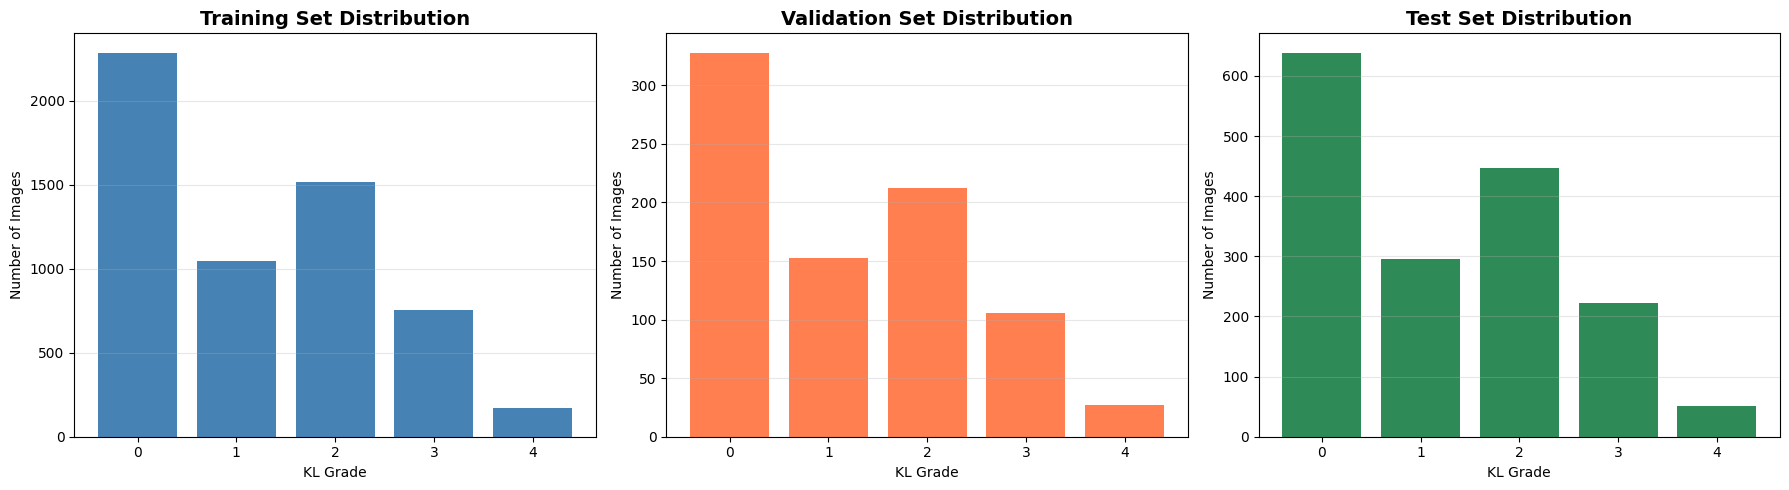

✓ Class distribution plot saved!

Total Training Images: 5778
Total Validation Images: 826
Total Test Images: 1656


In [6]:
# Collect data for visualization
train_counts = {'0': 2286, '1': 1046, '2': 1516, '3': 757, '4': 173}
val_counts = {'0': 328, '1': 153, '2': 212, '3': 106, '4': 27}
test_counts = {'0': 639, '1': 296, '2': 447, '3': 223, '4': 51}

# Create bar chart for class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train set
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue')
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('KL Grade')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)

# Val set
axes[1].bar(val_counts.keys(), val_counts.values(), color='coral')
axes[1].set_title('Validation Set Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('KL Grade')
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.3)

# Test set
axes[2].bar(test_counts.keys(), test_counts.values(), color='seagreen')
axes[2].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('KL Grade')
axes[2].set_ylabel('Number of Images')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution plot saved!")
print(f"\nTotal Training Images: {sum(train_counts.values())}")
print(f"Total Validation Images: {sum(val_counts.values())}")
print(f"Total Test Images: {sum(test_counts.values())}")


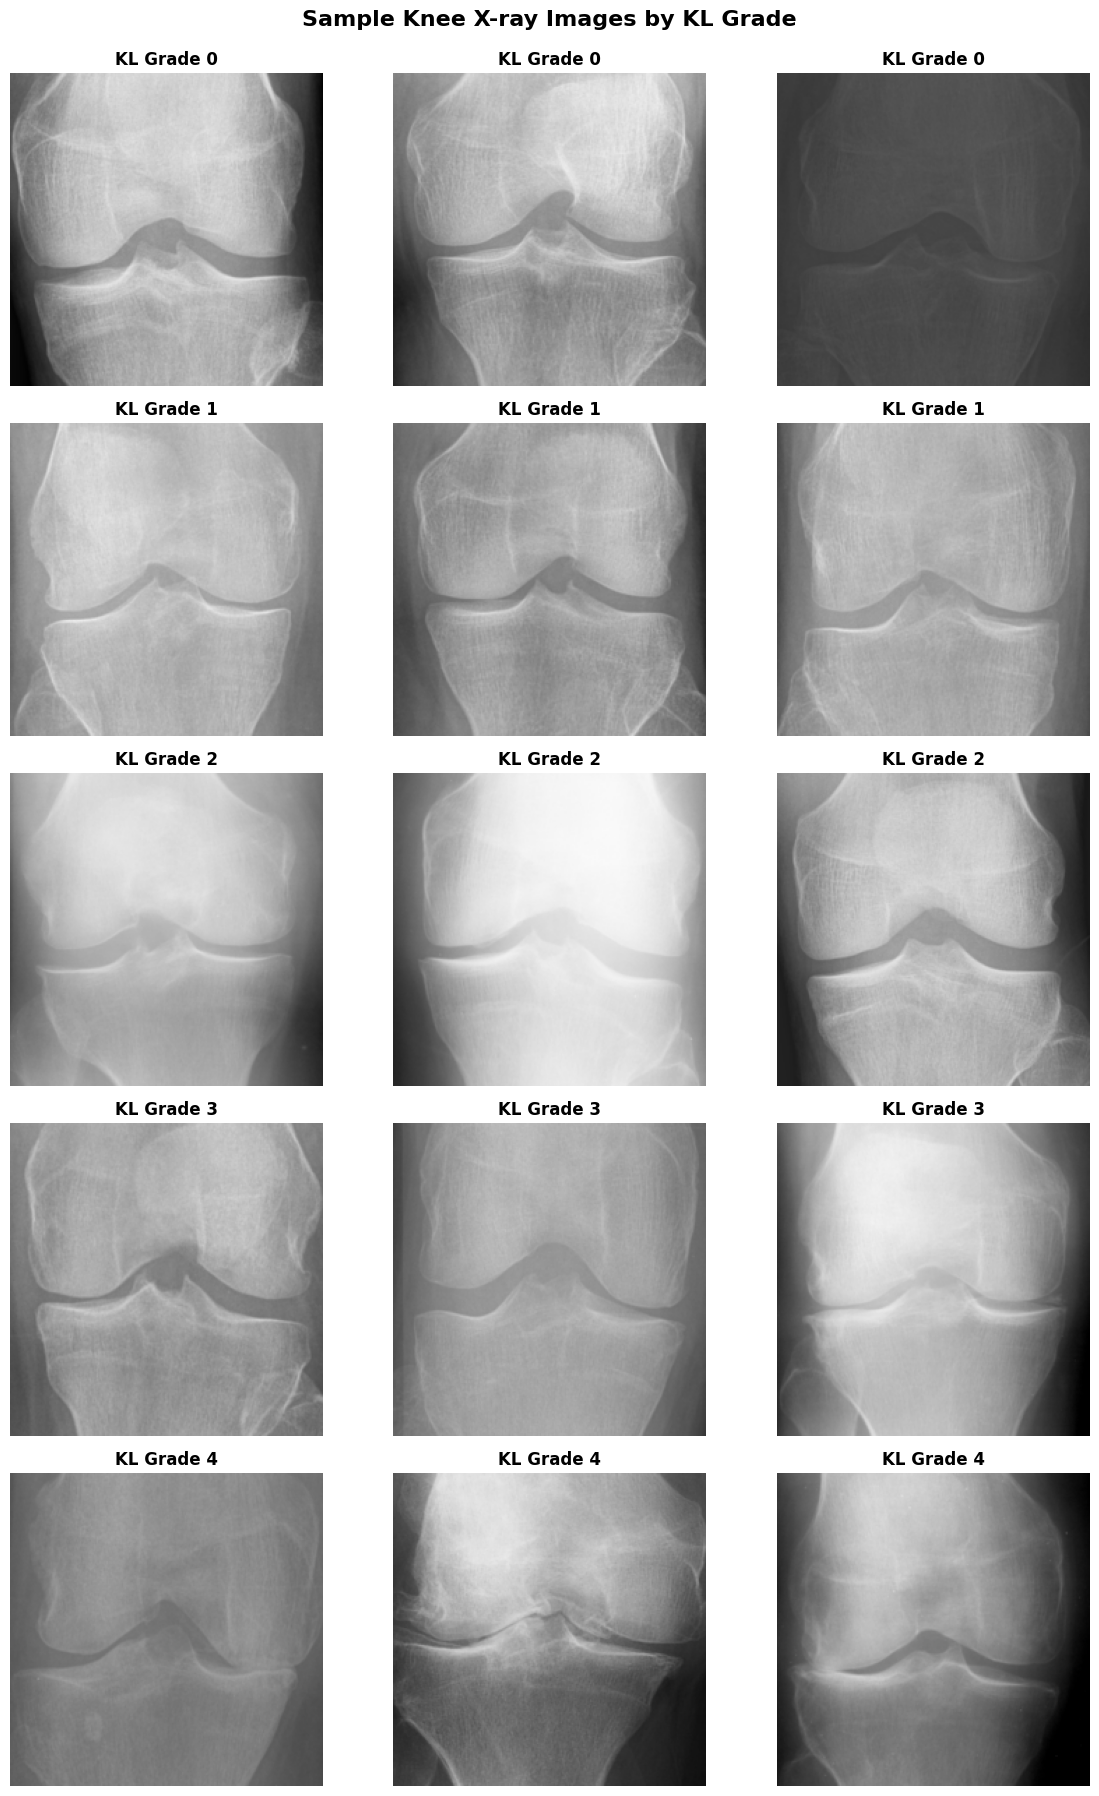

✓ Sample images visualization saved!


In [7]:
# Visualize sample images from each KL grade
DATA_PATH = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/'

fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.suptitle('Sample Knee X-ray Images by KL Grade', fontsize=16, fontweight='bold', y=0.995)

# For each KL grade (0-4)
for grade in range(5):
    grade_path = os.path.join(DATA_PATH, str(grade))
    image_files = os.listdir(grade_path)[:3]  # Get first 3 images

    # Display 3 sample images per grade
    for idx, img_file in enumerate(image_files):
        img_path = os.path.join(grade_path, img_file)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[grade, idx].imshow(img_rgb, cmap='gray')
        axes[grade, idx].axis('off')
        axes[grade, idx].set_title(f'KL Grade {grade}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('sample_images_per_grade.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample images visualization saved!")


Sample image files: ['9657071L.png', '9291206L.png', '9386991R.png', '9548815R.png', '9660607L.png']

Using image: /content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/0/9657071L.png

✓ Preprocessing function created!
Original pixel range: [0, 255]
Normalized pixel range: [0.004, 0.894]
Image shape: (224, 224, 3)


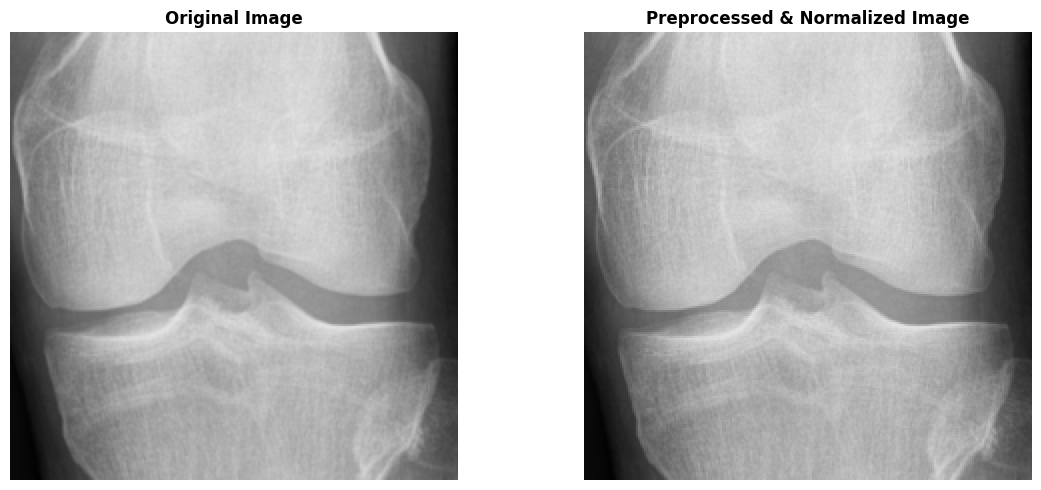


✓ Preprocessing visualization saved!


In [8]:
# First, let's find an actual image file
train_path = '/content/KneeXrayData/KneeXrayData/ClsKLData/kneeKL224/train/0/'
sample_images = os.listdir(train_path)[:5]
print(f"Sample image files: {sample_images}")

# Get the first image
first_image = sample_images[0]
test_img_path = os.path.join(train_path, first_image)
print(f"\nUsing image: {test_img_path}")

# Image preprocessing function
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    """
    Load and preprocess a single image
    - Resize to target size (already 224x224 in our dataset)
    - Normalize pixel values to [0, 1]
    """
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, target_size)
    img_normalized = img_resized / 255.0  # Normalize to [0, 1]
    return img_normalized

# Test the preprocessing function
preprocessed_img = load_and_preprocess_image(test_img_path)

print("\n✓ Preprocessing function created!")
print(f"Original pixel range: [0, 255]")
print(f"Normalized pixel range: [{preprocessed_img.min():.3f}, {preprocessed_img.max():.3f}]")
print(f"Image shape: {preprocessed_img.shape}")

# Visualize preprocessing effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
original = cv2.imread(test_img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
axes[0].imshow(original_rgb)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Preprocessed (normalized)
axes[1].imshow(preprocessed_img)
axes[1].set_title('Preprocessed & Normalized Image', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('preprocessing_example.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Preprocessing visualization saved!")
